## **Connect Colab**

In [1]:
import os, sys, subprocess
from getpass import getpass

os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

REPO   = "silvergjeka22/Unified-Lifelong-Action-Learning"
BRANCH = "embeddings"
ROOT   = "/content/ulal"

token = os.environ.get("GITHUB_TOKEN") or getpass("GitHub token: ")
os.environ["GITHUB_TOKEN"] = token

if os.path.isdir(os.path.join(ROOT, ".git")):
    subprocess.run(["git", "-C", ROOT, "fetch", "--depth", "1", "origin", BRANCH], check=True)
    subprocess.run(["git", "-C", ROOT, "reset", "--hard", "FETCH_HEAD"], check=True)
else:
    subprocess.run(["git", "clone", "--depth", "1", "--branch", BRANCH,
                    "https://" + token + "@github.com/" + REPO + ".git", ROOT], check=True)

if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

In [2]:
os.environ["KAGGLE_USERNAME"] = "colab"
os.environ["KAGGLE_KEY"]      = "PASTE_YOUR_KAGGLE_KEY"

## **Download DATASET**

Drive only - the cache and the base head are on Drive, no video needed.

In [3]:
from src.bootstrap import setup
setup(drive=True, dataset=False)

Mounted at /content/drive
Drive mounted.
ULAL_DATA_ROOT     = /content/UCF101
ULAL_DRIVE_PROJECT = /content/drive/MyDrive/apai
Setup complete — no config.py edit, no kernel restart.


In [4]:
# imports
%run /content/ulal/src/imports.py
set_seed(cfg.SEED)

ULAL_ROOT : /content/ulal
Device    : cuda
GPU       : Tesla T4 (15.6 GB)
Classes   : base=10 t1=10 t2=10 t3=10 t4=10


42

## **Load Cache and Base Head**

The base head is the same `head_base.pt` the continual-learning notebooks use, so the
feature space is identical. If it is not on Drive yet it is trained here on task 0.

In [5]:
CACHE, LSTM_STATE, META = load_feature_cache(cfg.FEAT_CACHE)

ALL_CLASSES_LIST = cfg.SELECTED_CLASSES + cfg.TASK_1 + cfg.TASK_2
check_cache_labels(META, ALL_CLASSES_LIST)

class_to_idx = {cls_name: i for i, cls_name in enumerate(ALL_CLASSES_LIST)}
print(f"base classes: {len(cfg.SELECTED_CLASSES)}")

Loaded 9 tensors, 526 MB in RAM
  per clip: (16, 2048)
base classes: 10


In [6]:
head = load_or_train_base_head(
    f"{cfg.CKPT_DIR}/head_base.pt", CACHE, LSTM_STATE, len(cfg.SELECTED_CLASSES), device,
)
print(f"head embedding dim: {cfg.TEACHER_HIDDEN}")

Loaded base head <- /content/drive/MyDrive/apai/checkpoints/head_base.pt
head embedding dim: 256


## **Feature Space (256-d)**

Run the base head over the cached frames and keep its 256-d output per clip. These real
features are what the generator will learn to reproduce. Train split trains the GAN, test
split checks it later.

In [7]:
real_feats, real_labels = head_embeddings(head, CACHE, [0], device, "train")
test_feats, test_labels = head_embeddings(head, CACHE, [0], device, "test")

print(f"real train feats: {tuple(real_feats.shape)}   labels {tuple(real_labels.shape)}")
print(f"real test  feats: {tuple(test_feats.shape)}")

real train feats: (953, 256)   labels (953,)
real test  feats: (212, 256)


## **Semantic Embeddings**

Each class name is embedded with all-MiniLM-L6-v2 (384-d). The discriminator and the
mutual-information term are conditioned on this vector. CamelCase names are split into
words first so "ApplyEyeMakeup" reads as "Apply Eye Makeup".

In [8]:
!pip install -q sentence-transformers

In [9]:
import re
from sentence_transformers import SentenceTransformer

class_sentences = [re.sub(r"(?<!^)(?=[A-Z])", " ", c) for c in cfg.SELECTED_CLASSES]
print(class_sentences)

sbert  = SentenceTransformer("all-MiniLM-L6-v2", device=str(device))
sem_np = sbert.encode(class_sentences, convert_to_numpy=True, normalize_embeddings=True)

print(f"semantic embeddings: {sem_np.shape}")

['Playing Tabla', 'Pommel Horse', 'Jumping Jack', 'Push Ups', 'Pole Vault', 'Horse Race', 'High Jump', 'Drumming', 'Horse Riding', 'Diving']


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

semantic embeddings: (10, 384)


## **Class Prototypes**

For each base class, store the mean and std of its real features, plus its semantic
vector. This is the whole memory footprint of GIL - a few KB per class, no clips.

In [10]:
FEAT_DIM = cfg.TEACHER_HIDDEN

class_stats = {}
for i in range(len(cfg.SELECTED_CLASSES)):
    mask = real_labels == i
    fc   = real_feats[mask]
    class_stats[i] = {
        "mu":    fc.mean(0),
        "sigma": fc.std(0).clamp_min(1e-6),
        "sem":   torch.tensor(sem_np[i], dtype=torch.float32),
    }

bytes_per_class = 2 * FEAT_DIM * class_stats[0]["mu"].element_size()
print(f"stored per class: mu+sigma = {bytes_per_class} bytes ({bytes_per_class/1e3:.1f} KB)")

stored per class: mu+sigma = 2048 bytes (2.0 KB)


## **Train the Generator**

WGAN-GP with a gradient penalty, an auxiliary classifier on the synthetic features, and a
mutual-information term back to the semantic space. `train_gan_real` sees the real per-clip
features, so it cannot win by collapsing to the class mean.

In [11]:
gen  = FeatureGenerator(feat_dim=FEAT_DIM, noise_dim=cfg.NOISE_DIM).to(device)
disc = Discriminator(feat_dim=FEAT_DIM, sem_dim=cfg.SEM_DIM).to(device)
proj = ProjectionHead(feat_dim=FEAT_DIM, sem_dim=cfg.SEM_DIM).to(device)

print(f"generator params: {sum(p.numel() for p in gen.parameters()):,}")

generator params: 20,979,968


In [12]:
set_seed(cfg.SEED)

gan_history = train_gan_real(
    gen, disc, proj, real_feats, real_labels, class_stats, device,
    epochs=cfg.GAN_EPOCHS, lam1=cfg.LAM1, lam2=cfg.LAM2, alpha=cfg.ALPHA_GP,
    lr=cfg.GAN_LR, batch_size=cfg.BATCH_SIZE_GAN, n_critic=cfg.N_CRITIC,
)

[GAN] Epoch 01/30  D: -8.2092  G: -0.7148  CLS: 2.2953
[GAN] Epoch 05/30  D: -3.2331  G: -0.3033  CLS: 1.9000
[GAN] Epoch 10/30  D: -3.4802  G: +0.4667  CLS: 1.4101
[GAN] Epoch 15/30  D: -3.3555  G: +0.8332  CLS: 0.9910
[GAN] Epoch 20/30  D: -3.1489  G: +1.1173  CLS: 0.7034
[GAN] Epoch 25/30  D: -2.7391  G: +1.6410  CLS: 0.4978
[GAN] Epoch 30/30  D: -2.7320  G: +1.6182  CLS: 0.3676
FeatureGenerator frozen.


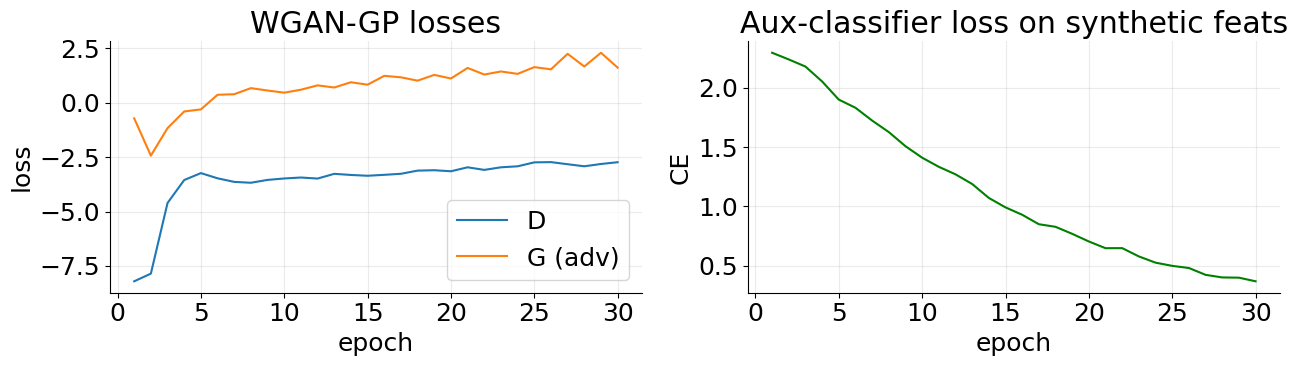

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
eps = range(1, len(gan_history["d_loss"]) + 1)

ax1.plot(eps, gan_history["d_loss"], label="D")
ax1.plot(eps, gan_history["g_loss"], label="G (adv)")
ax1.set_xlabel("epoch"); ax1.set_ylabel("loss"); ax1.set_title("WGAN-GP losses"); ax1.legend()

ax2.plot(eps, gan_history["cls_loss"], color="green")
ax2.set_xlabel("epoch"); ax2.set_ylabel("CE"); ax2.set_title("Aux-classifier loss on synthetic feats")

plt.tight_layout()
plt.savefig(f"{cfg.RESULTS_DIR}/gil_training.png", dpi=150, bbox_inches="tight")
plt.show()

## **Generate Embeddings**

Ask the frozen generator for J synthetic features per class, from (mu, sigma) plus fresh
noise each time. Nothing but the prototypes was stored.

In [14]:
J = cfg.J_SYNTH
gen.eval()

synth_list, synth_lab = [], []
with torch.no_grad():
    for i in range(len(cfg.SELECTED_CLASSES)):
        mu    = class_stats[i]["mu"].unsqueeze(0).expand(J, -1).to(device)
        sigma = class_stats[i]["sigma"].unsqueeze(0).expand(J, -1).to(device)
        xh    = gen(mu, sigma).cpu()
        synth_list.append(xh)
        synth_lab.extend([i] * J)

synth_feats  = torch.cat(synth_list)
synth_labels = torch.tensor(synth_lab)
print(f"generated: {tuple(synth_feats.shape)}  ({J} per class)")

generated: (500, 256)  (50 per class)


## **Real vs Generated**

The picture that answers "how does it generate the embeddings". A t-SNE of real (circles)
and generated (crosses) features. If the generation is good the crosses land inside the
matching real cluster and spread across it. If they pile onto a single point per class,
that is mode collapse.

In [15]:
n_per = J
real_sub, real_sub_lab = [], []
for i in range(len(cfg.SELECTED_CLASSES)):
    idx = (real_labels == i).nonzero(as_tuple=True)[0][:n_per]
    real_sub.append(real_feats[idx])
    real_sub_lab.extend([i] * len(idx))
real_sub     = torch.cat(real_sub)
real_sub_lab = torch.tensor(real_sub_lab)

X      = torch.cat([real_sub, synth_feats]).numpy()
origin = np.array([0] * len(real_sub) + [1] * len(synth_feats))
labs   = np.concatenate([real_sub_lab.numpy(), synth_labels.numpy()])

Xp = PCA(n_components=50, random_state=cfg.SEED).fit_transform(X) if X.shape[1] > 50 else X
xy = TSNE(n_components=2, random_state=cfg.SEED, init="pca", learning_rate="auto",
          perplexity=30).fit_transform(Xp)

print(f"projected {len(xy)} points")

projected 1000 points


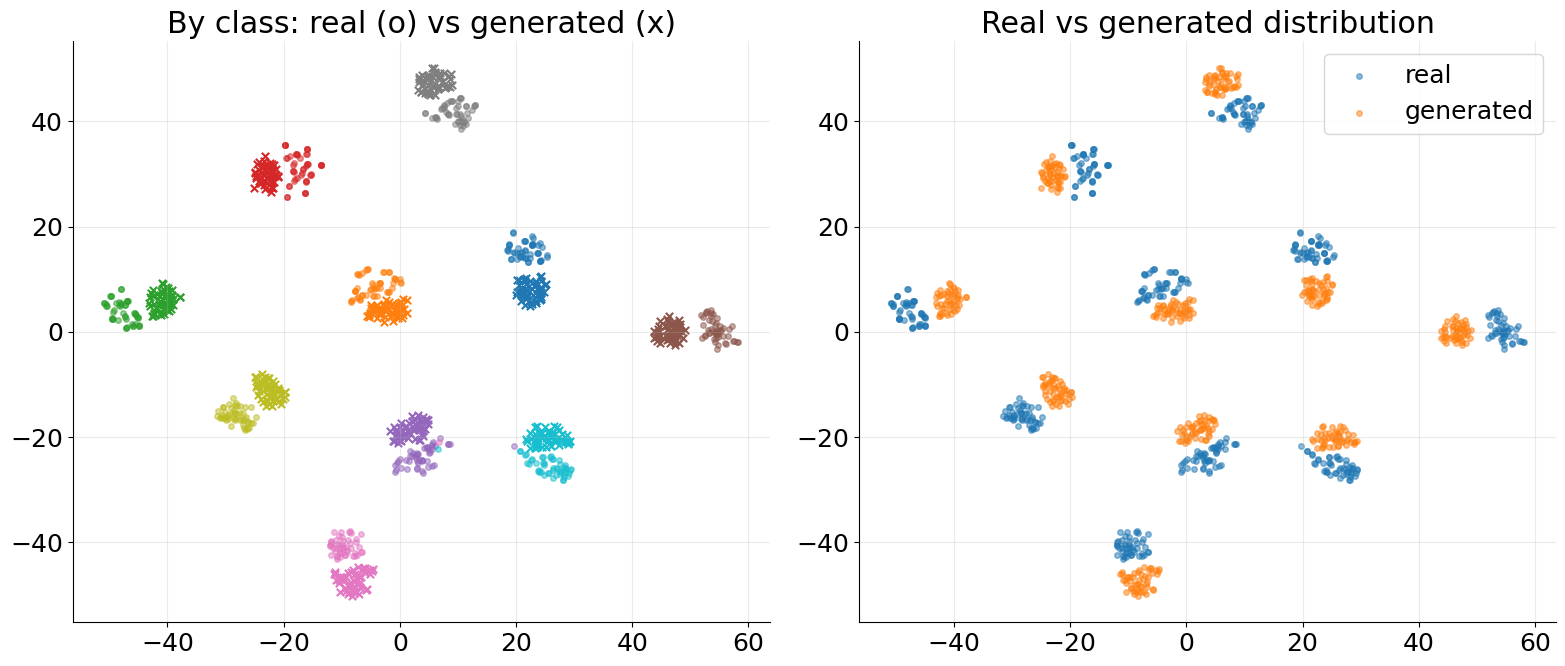

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
cmap = plt.get_cmap("tab10")

for i in range(len(cfg.SELECTED_CLASSES)):
    r = (labs == i) & (origin == 0)
    g = (labs == i) & (origin == 1)
    ax1.scatter(xy[r, 0], xy[r, 1], color=cmap(i % 10), marker="o", s=16, alpha=0.5)
    ax1.scatter(xy[g, 0], xy[g, 1], color=cmap(i % 10), marker="x", s=28)
ax1.set_title("By class: real (o) vs generated (x)")

ax2.scatter(xy[origin == 0, 0], xy[origin == 0, 1], s=16, alpha=0.5, label="real")
ax2.scatter(xy[origin == 1, 0], xy[origin == 1, 1], s=16, alpha=0.5, label="generated")
ax2.legend()
ax2.set_title("Real vs generated distribution")

plt.tight_layout()
plt.savefig(f"{cfg.RESULTS_DIR}/gil_real_vs_generated.png", dpi=150, bbox_inches="tight")
plt.show()

Per-class cosine similarity between the real centroid and the generated centroid. Near 1.0
means the generator centres each class correctly. Read it together with the plot: a high
cosine but a collapsed cloud would still be a bad generator.

In [17]:
print(f"{'class':<22}{'cos(real, gen) centroid':>26}")
print("-" * 48)
for i in range(len(cfg.SELECTED_CLASSES)):
    real_c = class_stats[i]["mu"]
    gen_c  = synth_feats[synth_labels == i].mean(0)
    cos    = F.cosine_similarity(real_c.unsqueeze(0), gen_c.unsqueeze(0)).item()
    print(f"{cfg.SELECTED_CLASSES[i]:<22}{cos:>26.3f}")

class                    cos(real, gen) centroid
------------------------------------------------
PlayingTabla                               0.938
PommelHorse                                0.944
JumpingJack                                0.945
PushUps                                    0.917
PoleVault                                  0.947
HorseRace                                  0.929
HighJump                                   0.949
Drumming                                   0.973
HorseRiding                                0.967
Diving                                     0.951


## **Does the Generation Carry the Classes?**

The honest test of generative replay: train a fresh classifier on ONLY the generated
features, then measure it on REAL test features. Compare against the same classifier
trained on real features. If the generated-only number is close, the generator is a usable
stand-in for stored data.

In [18]:
set_seed(cfg.SEED)
gen_clf = GILClassifier(feat_dim=FEAT_DIM, num_classes=len(cfg.SELECTED_CLASSES)).to(device)
gen_loader = DataLoader(TensorDataset(synth_feats, synth_labels), batch_size=64, shuffle=True)
fine_tune_last2(gen_clf, gen_loader, epochs=cfg.FT_EPOCHS, lr=cfg.FT_LR, device=device)

with torch.no_grad():
    gen_pred = gen_clf(test_feats.to(device)).argmax(1).cpu()
gen_acc = (gen_pred == test_labels).float().mean().item()

  [FT] Epoch 1/5  Loss 2.2587  Acc 18.80%
  [FT] Epoch 5/5  Loss 1.6388  Acc 94.00%


In [19]:
set_seed(cfg.SEED)
real_clf = GILClassifier(feat_dim=FEAT_DIM, num_classes=len(cfg.SELECTED_CLASSES)).to(device)
real_loader = DataLoader(TensorDataset(real_feats, real_labels), batch_size=64, shuffle=True)
fine_tune_last2(real_clf, real_loader, epochs=cfg.FT_EPOCHS, lr=cfg.FT_LR, device=device)

with torch.no_grad():
    real_pred = real_clf(test_feats.to(device)).argmax(1).cpu()
real_acc = (real_pred == test_labels).float().mean().item()

  [FT] Epoch 1/5  Loss 2.1743  Acc 29.91%
  [FT] Epoch 5/5  Loss 1.2268  Acc 96.85%


## **Control: plain Gaussian prototype**

The honest question: does the 21M-parameter generator beat simply sampling from
N(mu, sigma) - the stored prototype itself, two lines of code? If the classes are already
separable in 256-d, a plain Gaussian may match the GAN, which would mean the generator adds
nothing over cheap prototype replay. Same J samples per class, same classifier, same test.

In [20]:
set_seed(cfg.SEED)
gauss_list, gauss_lab = [], []
for i in range(len(cfg.SELECTED_CLASSES)):
    mu    = class_stats[i]["mu"]
    sigma = class_stats[i]["sigma"]
    samp  = mu.unsqueeze(0) + torch.randn(J, mu.shape[0]) * sigma.unsqueeze(0)
    gauss_list.append(samp)
    gauss_lab.extend([i] * J)

gauss_feats  = torch.cat(gauss_list)
gauss_labels = torch.tensor(gauss_lab)
print(f"Gaussian samples: {tuple(gauss_feats.shape)}  ({J} per class)")

Gaussian samples: (500, 256)  (50 per class)


In [21]:
set_seed(cfg.SEED)
gauss_clf = GILClassifier(feat_dim=FEAT_DIM, num_classes=len(cfg.SELECTED_CLASSES)).to(device)
gauss_loader = DataLoader(TensorDataset(gauss_feats, gauss_labels), batch_size=64, shuffle=True)
fine_tune_last2(gauss_clf, gauss_loader, epochs=cfg.FT_EPOCHS, lr=cfg.FT_LR, device=device)

with torch.no_grad():
    gauss_pred = gauss_clf(test_feats.to(device)).argmax(1).cpu()
gauss_acc = (gauss_pred == test_labels).float().mean().item()

  [FT] Epoch 1/5  Loss 2.2535  Acc 19.80%
  [FT] Epoch 5/5  Loss 1.7202  Acc 90.40%


In [22]:
print(f"trained on REAL features             -> real test acc: {real_acc:.2%}")
print(f"trained on GAUSSIAN N(mu, sigma)      -> real test acc: {gauss_acc:.2%}")
print(f"trained on GAN-GENERATED features     -> real test acc: {gen_acc:.2%}")
print(f"\nGAN vs Gaussian prototype: {gen_acc - gauss_acc:+.2%}")
print("The GAN earns its complexity." if gen_acc - gauss_acc > 0.01
      else "The GAN barely beats a plain Gaussian -- prototype replay is enough.")

trained on REAL features             -> real test acc: 87.74%
trained on GAUSSIAN N(mu, sigma)      -> real test acc: 86.79%
trained on GAN-GENERATED features     -> real test acc: 84.43%

GAN vs Gaussian prototype: -2.36%
The GAN barely beats a plain Gaussian -- prototype replay is enough.


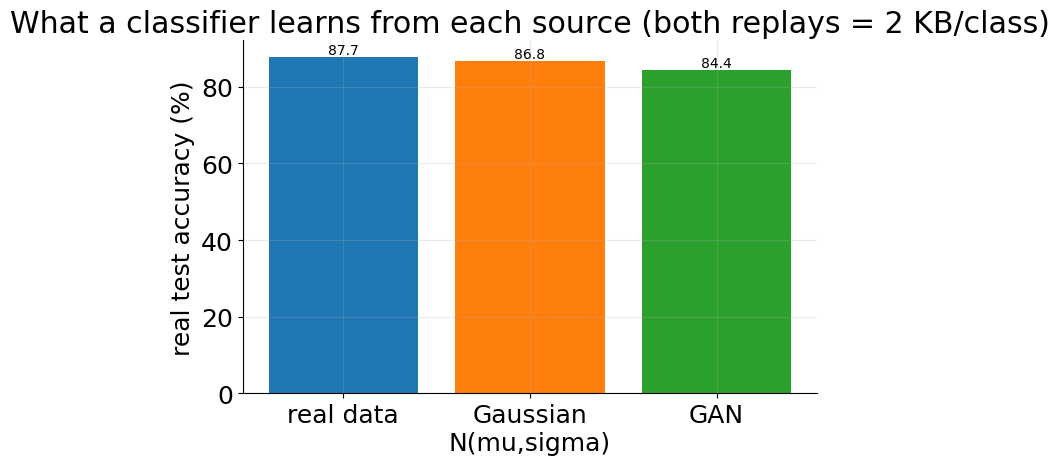

In [23]:
fig, ax = plt.subplots(figsize=(7, 5))
names  = ["real data", "Gaussian\nN(mu,sigma)", "GAN"]
scores = [real_acc, gauss_acc, gen_acc]
bars = ax.bar(names, [s * 100 for s in scores], color=["tab:blue", "tab:orange", "tab:green"])
ax.set_ylabel("real test accuracy (%)")
ax.set_title("What a classifier learns from each source (both replays = 2 KB/class)")
for b, s in zip(bars, scores):
    ax.annotate(f"{s*100:.1f}", (b.get_x() + b.get_width() / 2, s * 100),
                ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.savefig(f"{cfg.RESULTS_DIR}/stage6_gan_vs_gaussian.png", dpi=150, bbox_inches="tight")
plt.show()

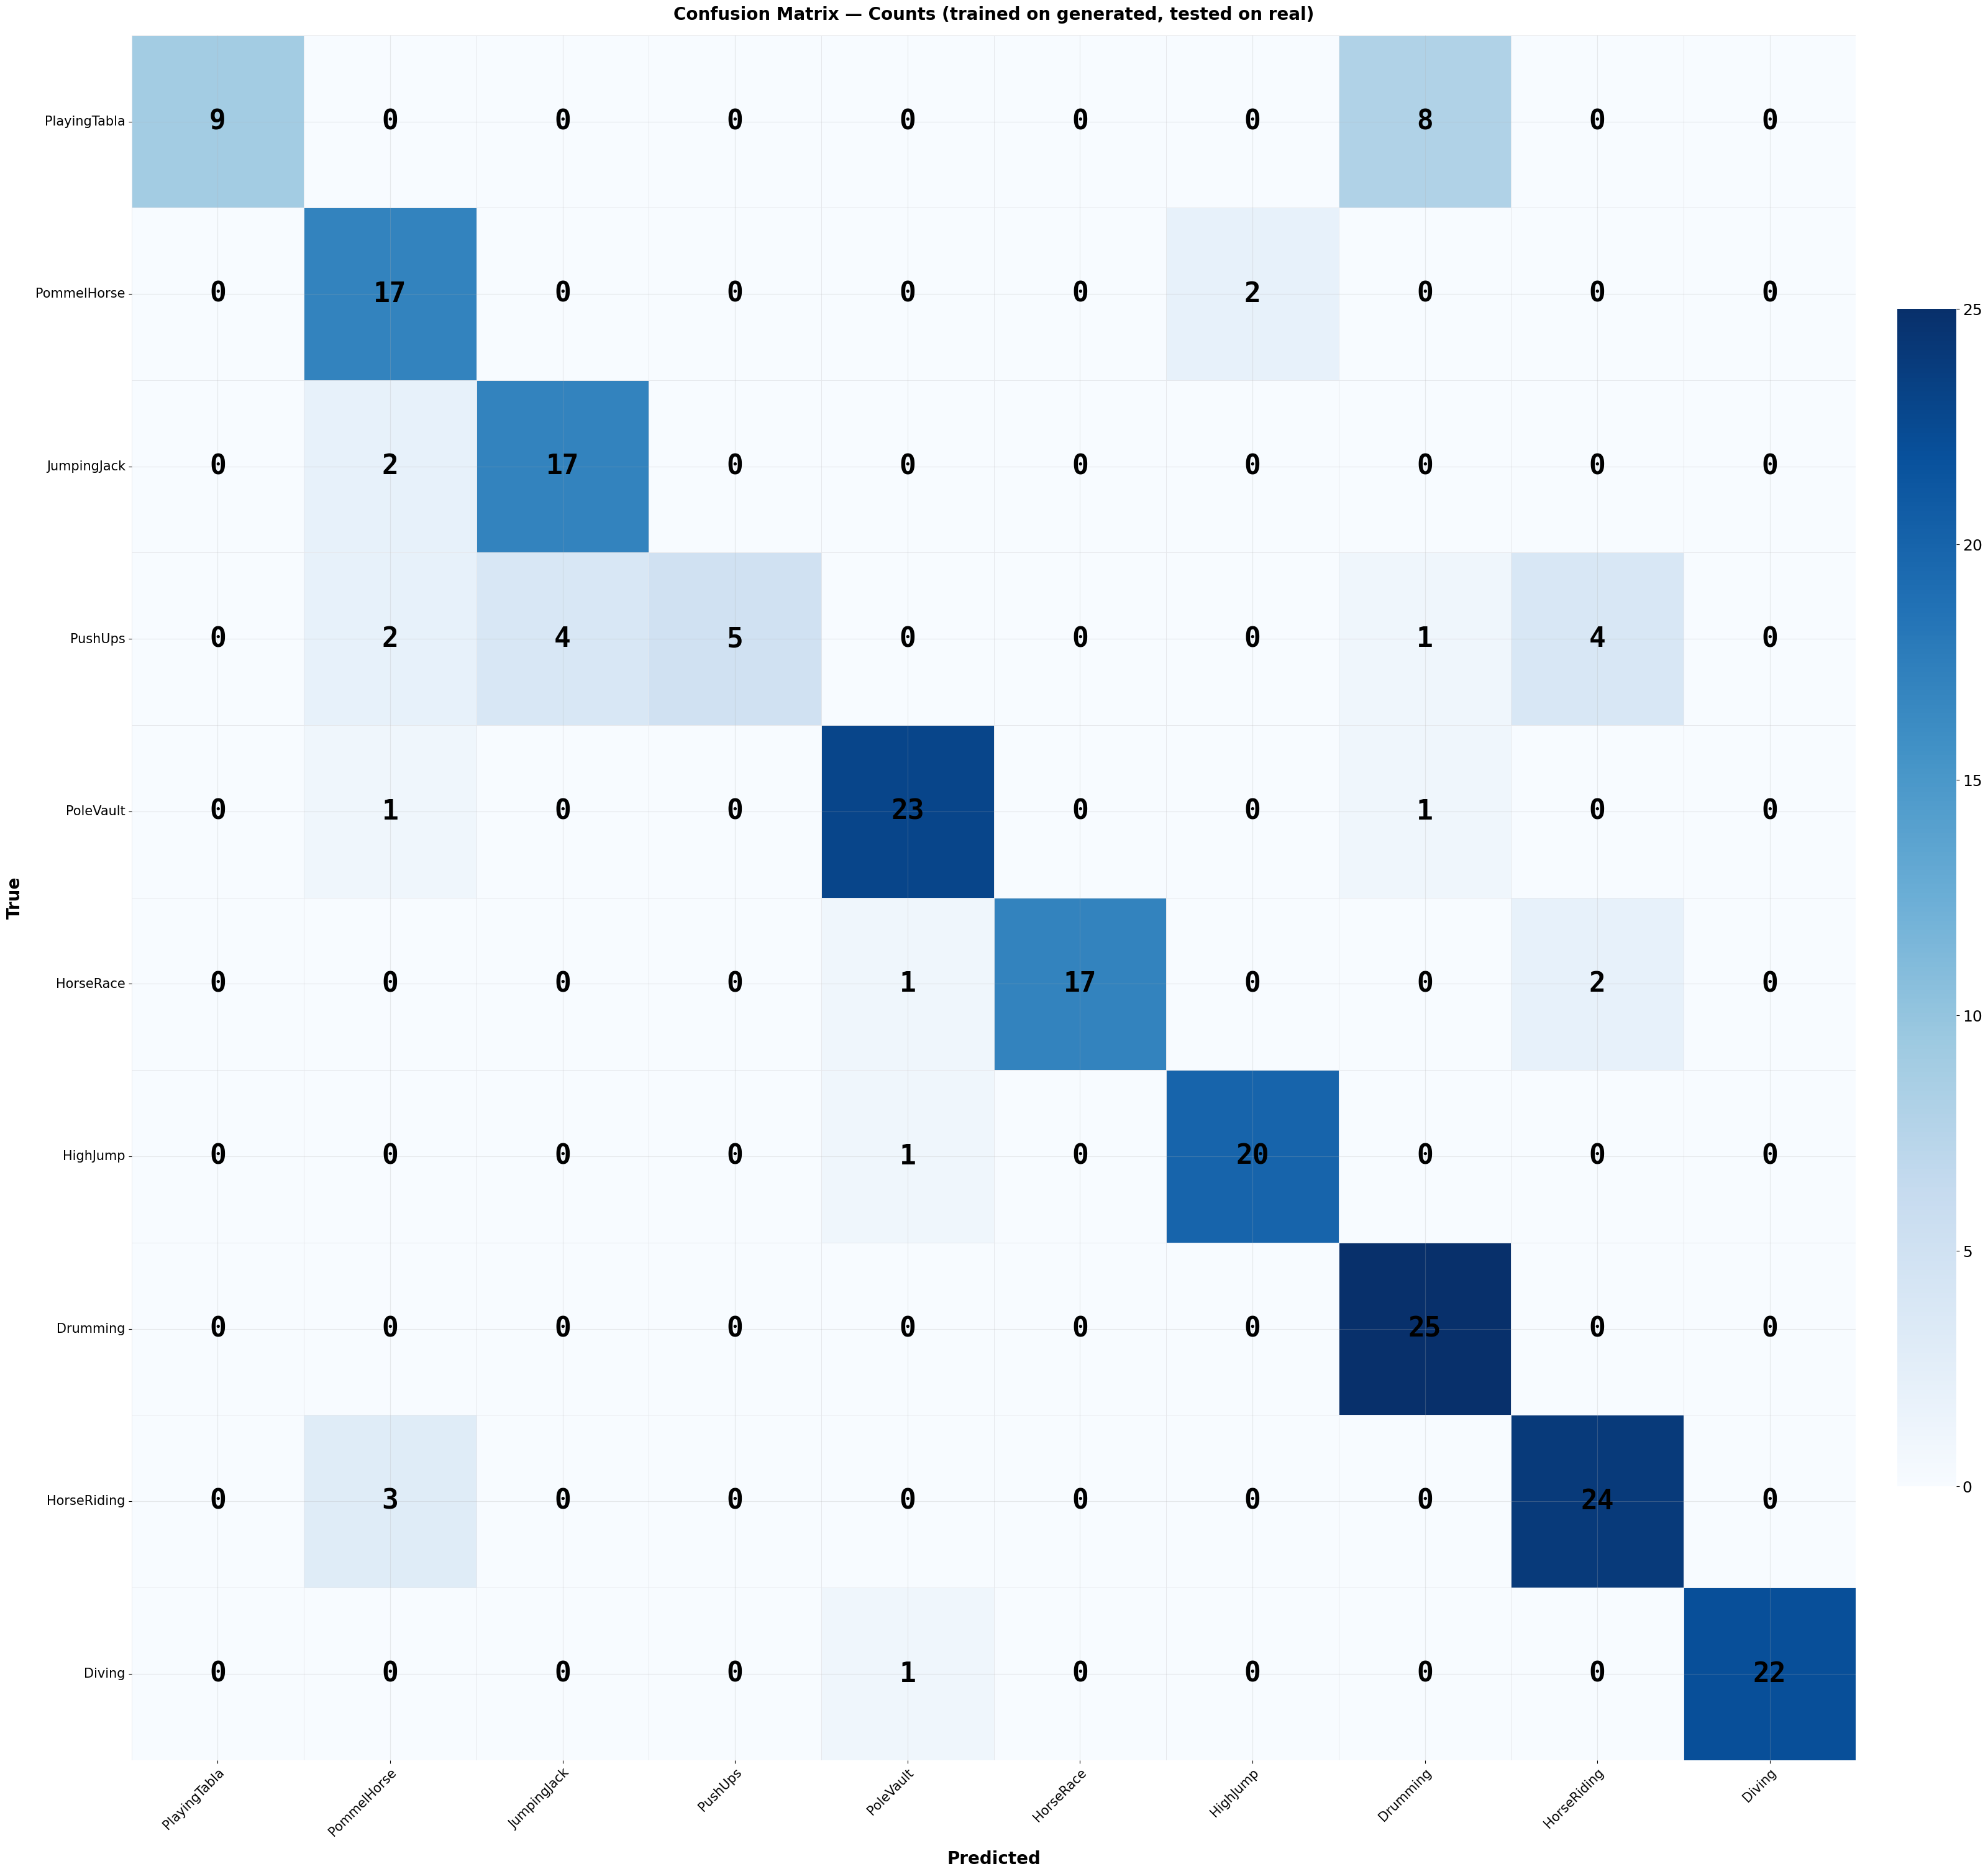

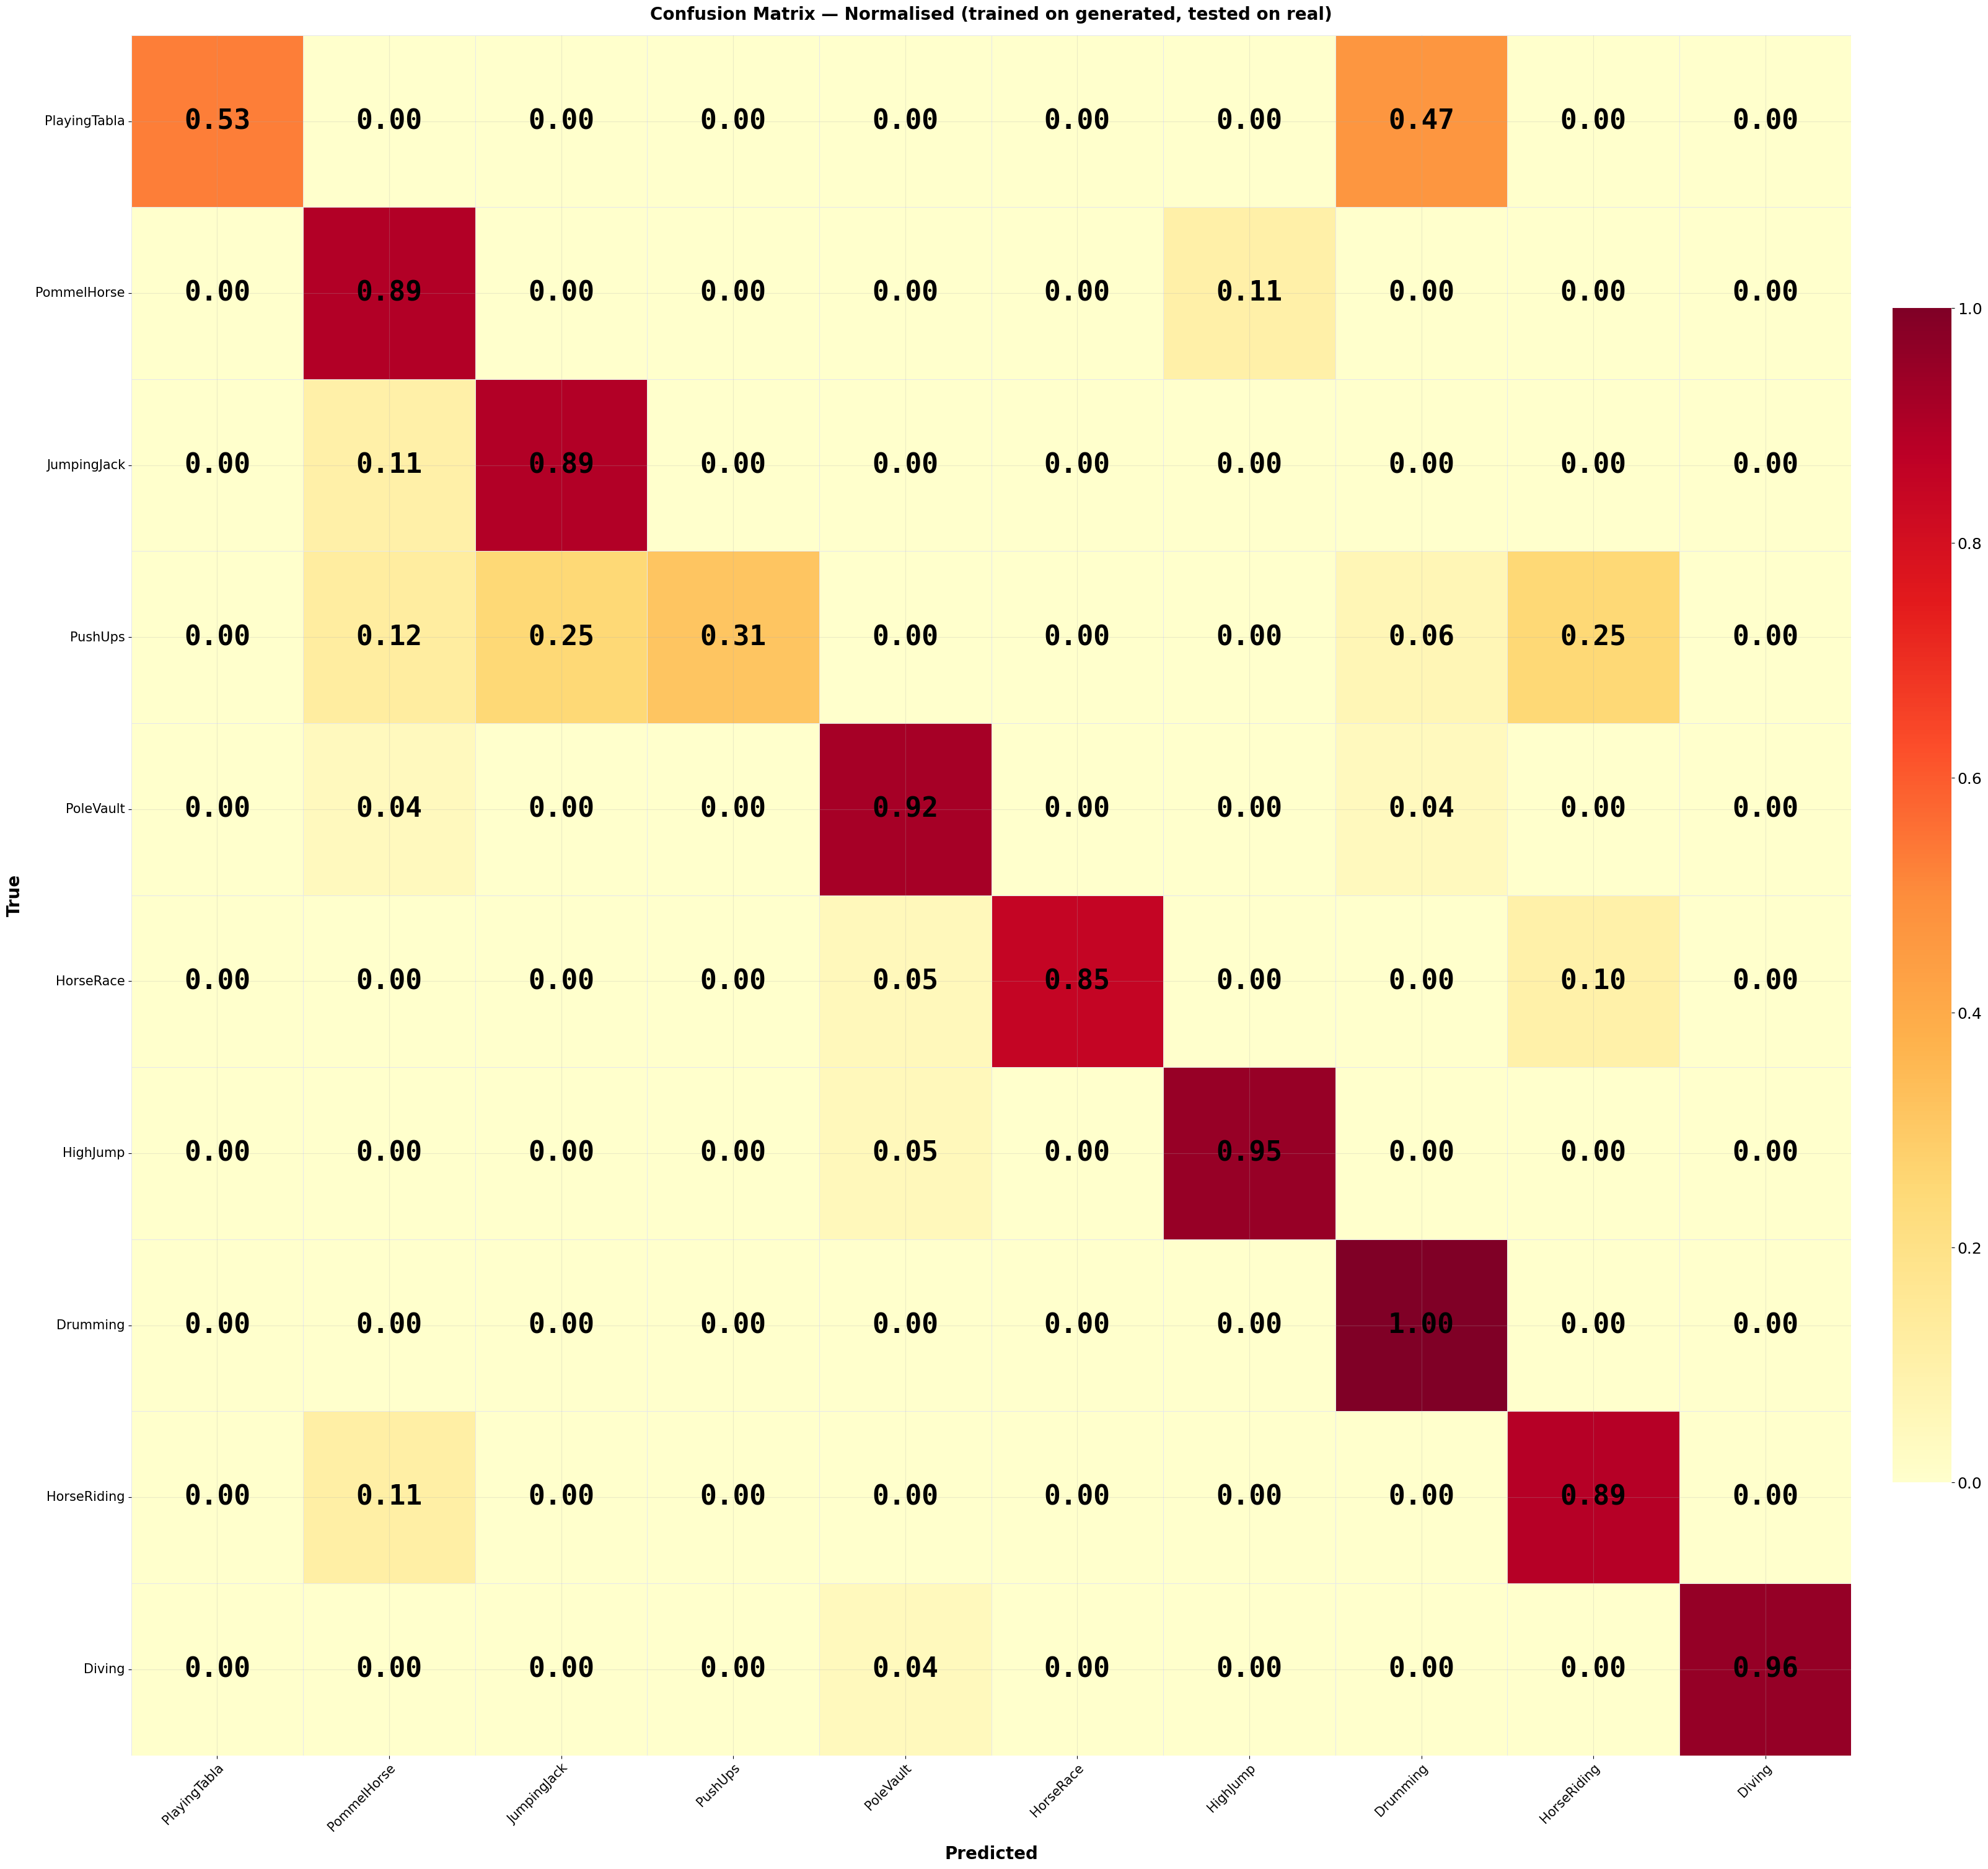

In [24]:
plot_confusion_matrix(
    test_labels.numpy(), gen_pred.numpy(),
    num_classes  = len(cfg.SELECTED_CLASSES),
    classes_list = cfg.SELECTED_CLASSES,
    name         = "trained on generated, tested on real",
    save_path    = f"{cfg.RESULTS_DIR}/gil_cm_generated",
)

## **Save**

Metrics and the generator, so a later notebook can reuse the frozen generator as replay.

In [25]:
gil_result = {
    "stage":           "6_gil_generative_replay",
    "classes":         cfg.SELECTED_CLASSES,
    "feat_dim":        FEAT_DIM,
    "bytes_per_class": int(bytes_per_class),
    "J_synth":         cfg.J_SYNTH,
    "real_test_acc":   float(real_acc),
    "gauss_test_acc":  float(gauss_acc),
    "gen_test_acc":    float(gen_acc),
    "gan_vs_gauss":    float(gen_acc - gauss_acc),
    "gap":             float(real_acc - gen_acc),
}

os.makedirs(cfg.RESULTS_DIR, exist_ok=True)
with open(f"{cfg.RESULTS_DIR}/stage6_gil.json", "w") as f:
    json.dump(gil_result, f, indent=2, default=float)

os.makedirs(cfg.GIL_CKPT_DIR, exist_ok=True)
torch.save(gen.state_dict(), f"{cfg.GIL_CKPT_DIR}/generator.pth")

print(f"Saved -> {cfg.RESULTS_DIR}/stage6_gil.json")
print(f"Saved -> {cfg.GIL_CKPT_DIR}/generator.pth")

Saved -> /content/drive/MyDrive/apai/results/stage6_gil.json
Saved -> /content/drive/MyDrive/apai/gil/generator.pth


## **See it as frames: nearest-clip retrieval**

An embedding is a 256-number vector - it cannot be turned back into pixels (the ResNet+LSTM
compression is one-way, so neither the GAN nor the Gaussian can output frames). The honest
way to SEE what the generator made: for a generated embedding, find the nearest REAL clip in
the 256-d space and show its frames. You are not reconstructing pixels; you are showing the
real video the generated point most resembles. This needs the raw base clips, so they are
downloaded and rebuilt here on demand.

In [26]:
from src.bootstrap import setup_dataset

if not clips_available([cfg.BASE_ROOT], "test"):
    ds_root, _ = setup_dataset()
    base_split = build_group_split(cfg.SELECTED_CLASSES, input_root=ds_root, train_groups=18, val_groups=3)
    preprocess_group_split(base_split, cfg.SELECTED_CLASSES, output_root=cfg.BASE_ROOT)

cfg.RESNET50_PATH = f"{cfg.DRIVE_PROJECT}/resnet50/models/ResNet50_10C_groupsplit.pth"
backbone = load_frozen_backbone(device, ResNet50LSTMTeacher, cfg.RESNET50_PATH,
                                hidden_size=cfg.TEACHER_HIDDEN, num_classes=len(cfg.SELECTED_CLASSES),
                                dropout_p=cfg.DROPOUT_P, remap_fn=remap_teacher_checkpoint)

c2i = {c: i for i, c in enumerate(cfg.SELECTED_CLASSES)}
base_test_ds, base_test_loader = build_clip_loader(cfg.BASE_ROOT, cfg.SELECTED_CLASSES, c2i, "test",
                                                   cfg.BATCH_SIZE, cfg.NUM_WORKERS, device.type == "cuda")

# extract embeddings from THESE clips, so the retrieval pool is aligned by construction
retr_2048, retr_y = extract_frame_features(backbone, base_test_loader, device, cfg.BACKBONE_DIM, torch.float32)
retr_feats = head.embed(retr_2048.to(device)).cpu()
print(f"retrieval pool: {len(base_test_ds)} real base-test clips  embeddings {tuple(retr_feats.shape)}")

100%|██████████| 6.53G/6.53G [05:21<00:00, 21.8MB/s]  

Extracting files...


ULAL_DATASET_ROOT = /root/.cache/kagglehub/datasets/matthewjansen/ucf101-action-recognition/versions/4/
ULAL_OUTPUT_ROOT  = /content/ucf101-processed/

--- Preprocessing (group-disjoint) ---
To  : /content/UCF101/grouped_base
Classes: 10

Processing split: train



Processing split: val



Processing split: test



Done! Dataset ready at: /content/UCF101/grouped_base
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 172MB/s]


  Dropped 53 num_batches_tracked buffer(s).


  Frame features: 100%|██████████| 27/27 [00:13<00:00,  1.98it/s]

retrieval pool: 212 real base-test clips  embeddings (212, 256)


In [27]:
dists  = torch.cdist(synth_feats, retr_feats)
nn_idx = dists.argmin(1)
nn_lab = retr_y[nn_idx]
retrieval_acc = (nn_lab == synth_labels).float().mean().item()
print(f"generated embedding -> nearest real clip is the SAME class: {retrieval_acc:.2%}")

generated embedding -> nearest real clip is the SAME class: 99.60%


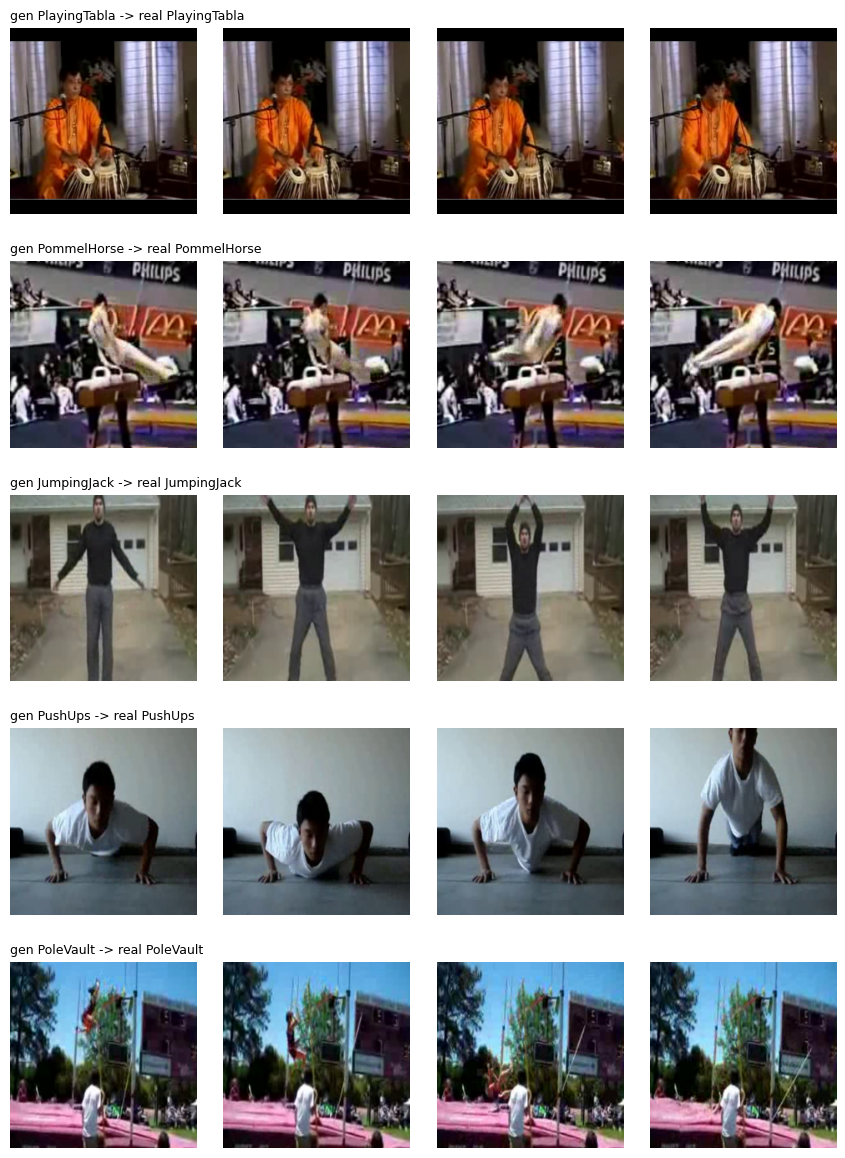

In [28]:
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
frame_ids = [0, 5, 10, 15]
show = list(range(5))

fig, axes = plt.subplots(len(show), len(frame_ids), figsize=(len(frame_ids) * 2.2, len(show) * 2.4))
for row, cls in enumerate(show):
    g_idx = (synth_labels == cls).nonzero(as_tuple=True)[0][0].item()
    r_idx = dists[g_idx].argmin().item()
    path, lbl = base_test_ds.samples[r_idx]
    clip = torch.load(path)
    for col, f in enumerate(frame_ids):
        frame = (clip[f] * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
        axes[row, col].imshow(frame)
        axes[row, col].axis("off")
    axes[row, 0].set_title(f"gen {cfg.SELECTED_CLASSES[cls]} -> real {cfg.SELECTED_CLASSES[lbl]}",
                           fontsize=9, loc="left")

plt.tight_layout()
plt.savefig(f"{cfg.RESULTS_DIR}/stage6_retrieval.png", dpi=150, bbox_inches="tight")
plt.show()